Train shape: (1296675, 23)
Test shape: (555719, 23)

Class distribution (train):
is_fraud
0    0.994211
1    0.005789
Name: proportion, dtype: float64

After SMOTE class distribution:
is_fraud
0    0.5
1    0.5
Name: proportion, dtype: float64

Logistic Regression
Accuracy: 0.8828 | Precision: 0.0365 | Recall: 0.7582 | F1: 0.0696
              precision    recall  f1-score   support

           0       1.00      0.88      0.94    257834
           1       0.04      0.76      0.07      1501

    accuracy                           0.88    259335
   macro avg       0.52      0.82      0.50    259335
weighted avg       0.99      0.88      0.93    259335


Decision Tree
Accuracy: 0.9476 | Precision: 0.0953 | Recall: 0.9487 | F1: 0.1731
              precision    recall  f1-score   support

           0       1.00      0.95      0.97    257834
           1       0.10      0.95      0.17      1501

    accuracy                           0.95    259335
   macro avg       0.55      0.95      0.

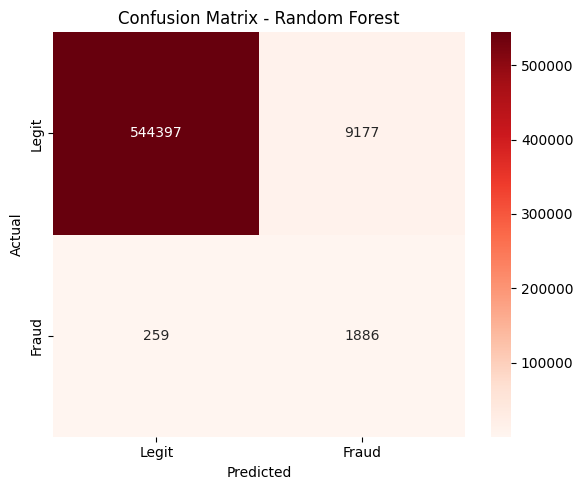

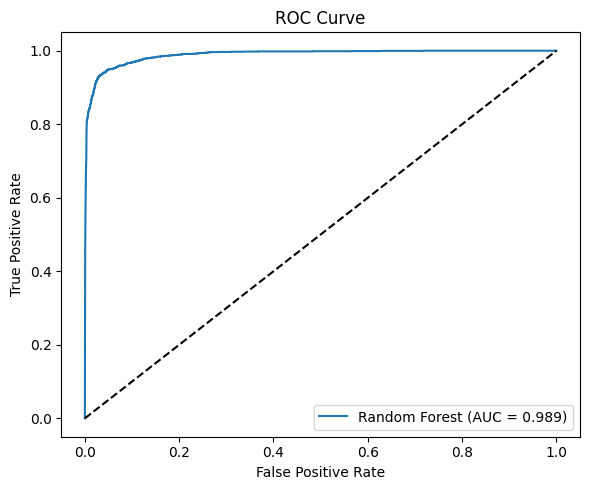


Task 2 completed successfully!


In [1]:
# =========================================================
# TASK 2: CREDIT CARD FRAUD DETECTION
# =========================================================

# ---------- 1. IMPORT LIBRARIES ----------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_auc_score, roc_curve)

# If this import fails, run this in a separate cell first: !pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# ---------- 2. LOAD DATASET ----------
# IMPORTANT: Update these paths to match YOUR dataset. Run this first if unsure:
# import os
# for dirname, _, filenames in os.walk('/kaggle/input'):
#     for filename in filenames:
#         print(os.path.join(dirname, filename))
train_path = "/kaggle/input/datasets/kartik2112/fraud-detection/fraudTrain.csv"
test_path = "/kaggle/input/datasets/kartik2112/fraud-detection/fraudTest.csv"

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
train_df.head()

# ---------- 3. BASIC CLEANING ----------
drop_cols = ["Unnamed: 0", "trans_date_trans_time", "cc_num", "merchant", "first",
             "last", "street", "city", "state", "zip", "job", "dob", "trans_num",
             "unix_time"]

train_df = train_df.drop(columns=[c for c in drop_cols if c in train_df.columns])
test_df = test_df.drop(columns=[c for c in drop_cols if c in test_df.columns])

cat_cols = train_df.select_dtypes(include="object").columns.tolist()
if "is_fraud" in cat_cols:
    cat_cols.remove("is_fraud")

train_df = pd.get_dummies(train_df, columns=cat_cols, drop_first=True)
test_df = pd.get_dummies(test_df, columns=cat_cols, drop_first=True)

train_df, test_df = train_df.align(test_df, join="left", axis=1, fill_value=0)

# ---------- 4. SPLIT FEATURES / TARGET ----------
X_train_full = train_df.drop(columns=["is_fraud"])
y_train_full = train_df["is_fraud"]

X_test = test_df.drop(columns=["is_fraud"])
y_test = test_df["is_fraud"]

print("\nClass distribution (train):")
print(y_train_full.value_counts(normalize=True))

# ---------- 5. TRAIN-VALIDATION SPLIT ----------
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42, stratify=y_train_full
)

# ---------- 6. SCALING ----------
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# ---------- 7. HANDLE IMBALANCE WITH SMOTE ----------
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print("\nAfter SMOTE class distribution:")
print(pd.Series(y_train_res).value_counts(normalize=True))

# ---------- 8. MODEL TRAINING & COMPARISON ----------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
}

results = {}
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    val_preds = model.predict(X_val_scaled)

    acc = accuracy_score(y_val, val_preds)
    prec = precision_score(y_val, val_preds)
    rec = recall_score(y_val, val_preds)
    f1 = f1_score(y_val, val_preds)

    results[name] = {"model": model, "f1": f1}
    print(f"\n{name}")
    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}")
    print(classification_report(y_val, val_preds))

# ---------- 9. SELECT BEST MODEL ----------
best_model_name = max(results, key=lambda k: results[k]["f1"])
best_model = results[best_model_name]["model"]
print(f"\nBest Model: {best_model_name}")

# ---------- 10. FINAL EVALUATION ON TEST SET ----------
test_preds = best_model.predict(X_test_scaled)
test_probs = best_model.predict_proba(X_test_scaled)[:, 1]

print("\n=== FINAL TEST SET RESULTS ===")
print("Accuracy:", accuracy_score(y_test, test_preds))
print("Precision:", precision_score(y_test, test_preds))
print("Recall:", recall_score(y_test, test_preds))
print("F1 Score:", f1_score(y_test, test_preds))
print("ROC-AUC:", roc_auc_score(y_test, test_probs))
print(classification_report(y_test, test_preds))

# ---------- 11. CONFUSION MATRIX ----------
cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Reds",
            xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig("confusion_matrix_task2.png", dpi=150)
plt.show()

# ---------- 12. ROC CURVE ----------
fpr, tpr, _ = roc_curve(y_test, test_probs)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"{best_model_name} (AUC = {roc_auc_score(y_test, test_probs):.3f})")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.savefig("roc_curve_task2.png", dpi=150)
plt.show()

print("\nTask 2 completed successfully!")